In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Air Traffic Data Stationary.csv",parse_dates=['Date'],index_col='Date')
df.head()

,domestic passengers_log_diff,international passenegrs_log_diff,domestic freight(in tonne)_log_diff,international freight(in tonne)_log_diff,GDP (in dollars)_log_diff,Population,Jet Fuel Price per Gallon_log_diff,Inflation Rate _log_diff,Unemployement Rate_log_diff,Rupees Exchange Rate_log_diff
Date,,,,,,,,,,
2009-01-02,0.001585,-0.156494,-0.110912,0.066838,0.0,1225524753,-0.146537,0.0,0.0,0.011230
2009-01-03,-0.053264,0.113350,0.211914,0.207414,0.0,1225524753,0.047891,0.0,0.0,0.037462
2009-01-04,0.045174,0.015990,-0.063735,-0.056726,0.0,1225524753,0.053022,0.0,0.0,-0.022949
2009-01-05,0.173060,0.041702,-0.101601,0.005086,0.0,1225524753,0.052154,0.0,0.0,-0.029653
2009-01-06,-0.063824,0.005875,0.149680,0.003217,0.0,1225524753,0.177301,0.0,0.0,-0.017468


In [23]:
df_new = df.copy()
df_new = df_new.drop(columns=['GDP (in dollars)_log_diff','Population','Jet Fuel Price per Gallon_log_diff','Inflation Rate _log_diff','Unemployement Rate_log_diff','Rupees Exchange Rate_log_diff'])

Stationarity Check using AD Fuller Test

In [4]:
def adf_test(series, name=''):
    result = adfuller(series.dropna())
    print(f'ADF Test for {name}: p-value = {result[1]}')
    if result[1] > 0.05:
        print("   ❌ Non-stationary, differencing needed")
    else:
        print("   ✅ Stationary")

In [5]:
for col in df_new.columns:
    adf_test(df_new[col], name=col)

ADF Test for domestic passengers_log_diff: p-value = 0.00064056279302921
   ✅ Stationary
ADF Test for international passenegrs_log_diff: p-value = 4.0644006764424425e-19
   ✅ Stationary
ADF Test for domestic freight(in tonne)_log_diff: p-value = 0.00041481201693734516
   ✅ Stationary
ADF Test for international freight(in tonne)_log_diff: p-value = 3.2943114567044314e-21
   ✅ Stationary


Selecting the Lag value using AIC

In [6]:
train_size = int(len(df_new) * 0.8)
train, test = df_new.iloc[:train_size], df_new.iloc[train_size:]

In [7]:
model = VAR(train)
lag_order = model.select_order(maxlags=12)
print(lag_order.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -13.59      -13.51   1.248e-06      -13.56
1       -15.22     -14.80*   2.462e-07      -15.05
2       -15.35      -14.59   2.167e-07      -15.04
3       -15.46      -14.37   1.932e-07      -15.02
4       -15.51      -14.08   1.844e-07      -14.93
5       -15.56      -13.79   1.770e-07      -14.84
6       -15.50      -13.40   1.891e-07      -14.64
7       -15.55      -13.12   1.804e-07      -14.56
8       -15.57      -12.80   1.791e-07      -14.44
9       -15.69      -12.58   1.617e-07      -14.43
10      -15.69      -12.24   1.654e-07      -14.29
11      -16.00      -12.22   1.240e-07      -14.46
12     -16.83*      -12.71  5.559e-08*     -15.16*
--------------------------------------------------


VAR Model Fitting

In [8]:
selected_lag = lag_order.aic
results = model.fit(selected_lag)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 25, Oct, 2025
Time:                     15:03:43
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -12.7105
Nobs:                     140.000    HQIC:                  -15.1552
Log likelihood:           579.408    FPE:                5.55927e-08
AIC:                     -16.8288    Det(Omega_mle):     1.67372e-08
--------------------------------------------------------------------
Results for equation domestic passengers_log_diff
                                                  coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------------------------------
const                                                0.013544         0.010757            1.259           0.208
L1.domestic passengers_lo

In [ ]:
forecast = results.forecast(train.values, steps=len(test))
forecast_df = pd.DataFrame(forecast,index=test.index,columns=test.columns)

In [15]:
last_log_value_anchor = train.iloc[-1]

In [16]:
forecast_log = forecast_df.cumsum() + last_log_value_anchor
forecast_original = np.exp(forecast_log)

In [10]:
print("\nForecasted values:")
print(forecast_df)


Forecasted values:
            domestic passengers_log_diff  international passenegrs_log_diff  \
Date                                                                          
2021-01-10                     -0.330913                          -0.109342   
2021-01-11                     -0.030303                          -0.401252   
2021-01-12                      0.108932                          -0.006544   
2022-01-01                      0.539221                           0.808828   
2022-01-02                      0.468010                           1.252114   
2022-01-03                      0.481424                           1.906868   
2022-01-04                      1.166159                          -0.315466   
2022-01-05                     -0.907683                          -2.967039   
2022-01-06                     -1.338209                          -1.519059   
2022-01-07                     -0.450253                           1.247744   
2022-01-08                      

Plotting Results

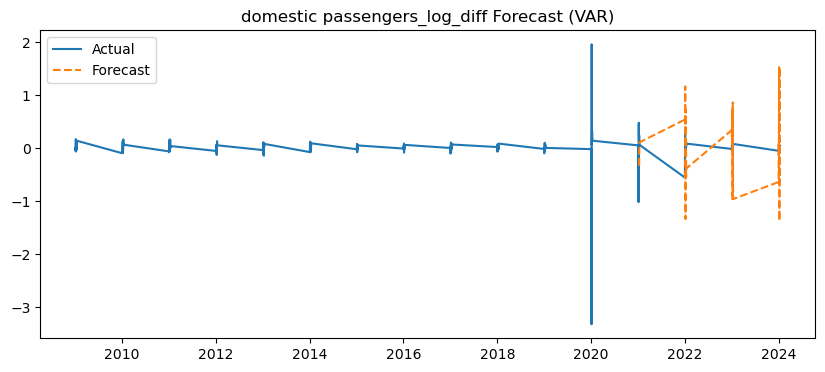

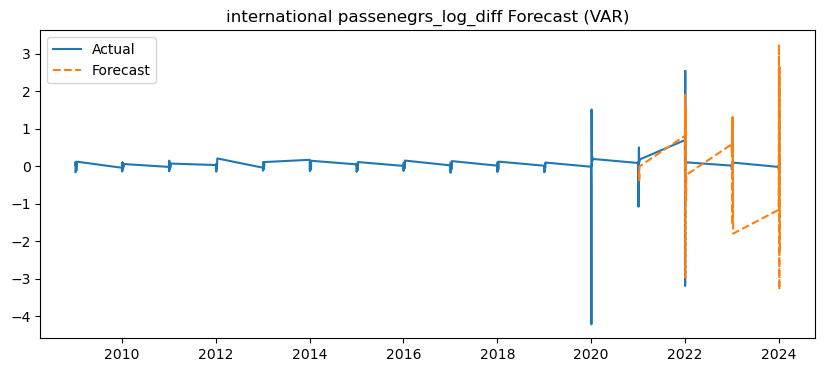

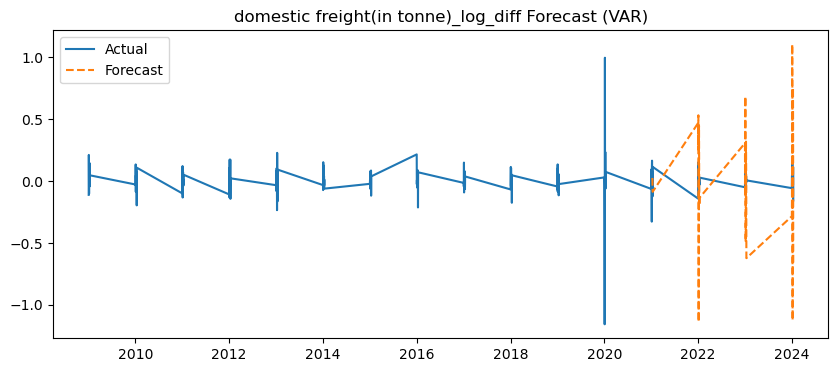

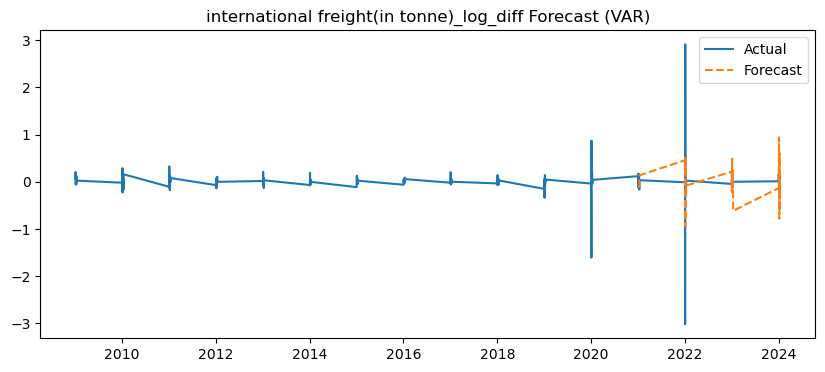

In [18]:
for col in df_new.columns:
    plt.figure(figsize=(10, 4))
    plt.plot(df_new[col], label='Actual')
    plt.plot(forecast_df[col], label='Forecast', linestyle='--')
    plt.title(f'{col} Forecast (VAR)')
    plt.legend()
    plt.show()

Evaluation Metrics

In [19]:
from sklearn.metrics import mean_squared_error , mean_absolute_percentage_error


def evaluate_forecast(test, y_pred):
    metrics = {}
    for col in test.columns:
        mae = mean_absolute_error(test[col], y_pred[col])
        rmse = np.sqrt(mean_squared_error(test[col], y_pred[col]))
        mape = mean_absolute_percentage_error(test[col], y_pred[col])
        metrics[col] = {"MAE": mae, "RMSE": rmse, "MAPE": mape}
    return metrics

results = evaluate_forecast(test, forecast_original)

In [20]:
for col, vals in results.items():
    print(f"{col}:\n MAE={vals['MAE']:.2f}\n RMSE={vals['RMSE']:.2f}\n MAPE={vals['MAPE']:.2f}%\n")

domestic passengers_log_diff:
 MAE=3.31
 RMSE=4.41
 MAPE=568.92%

international passenegrs_log_diff:
 MAE=10.72
 RMSE=20.83
 MAPE=761090019956957.75%

domestic freight(in tonne)_log_diff:
 MAE=1.89
 RMSE=2.15
 MAPE=114.41%

international freight(in tonne)_log_diff:
 MAE=1.90
 RMSE=2.17
 MAPE=280286150599838.81%



**From the aboce evaulation we are getting an AIC = -16.83**

In [21]:
print("--- Final, Interpretable Accuracy Metrics ---")
print("Comparing final forecasts against original test data:\n")

for col in test.columns:
    actuals = test[col]
    forecasts = forecast_original[col]
    
    # Calculate the metrics
    mae = mean_absolute_error(actuals, forecasts)
    rmse = np.sqrt(mean_squared_error(actuals, forecasts)) # or np.sqrt(mean_squared_error(...))
    mape = mean_absolute_percentage_error(actuals, forecasts)
    
    print(f"Metrics for: {col}")
    print(f"  MAE:  {mae:,.2f} (The average error is {mae:,.0f} units)")
    print(f"  RMSE: {rmse:,.2f} (Penalizes large errors)")
    print(f"  MAPE: {mape * 100:.2f}% (The average forecast is {mape*100:.2f}% off)")
    print("-" * 30)

--- Final, Interpretable Accuracy Metrics ---
Comparing final forecasts against original test data:

Metrics for: domestic passengers_log_diff
  MAE:  3.31 (The average error is 3 units)
  RMSE: 4.41 (Penalizes large errors)
  MAPE: 56891.82% (The average forecast is 56891.82% off)
------------------------------
Metrics for: international passenegrs_log_diff
  MAE:  10.72 (The average error is 11 units)
  RMSE: 20.83 (Penalizes large errors)
  MAPE: 76109001995695776.00% (The average forecast is 76109001995695776.00% off)
------------------------------
Metrics for: domestic freight(in tonne)_log_diff
  MAE:  1.89 (The average error is 2 units)
  RMSE: 2.15 (Penalizes large errors)
  MAPE: 11441.24% (The average forecast is 11441.24% off)
------------------------------
Metrics for: international freight(in tonne)_log_diff
  MAE:  1.90 (The average error is 2 units)
  RMSE: 2.17 (Penalizes large errors)
  MAPE: 28028615059983880.00% (The average forecast is 28028615059983880.00% off)
---